In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import cv2
from collections import deque, defaultdict
from ultralytics import YOLO
import csv

model = YOLO("/home/debasish/Documents/YOLOv8/runs/pose/train4/weights/best.pt")

tolerances = [50]
min_durations = [10]

for tolerance in tolerances:
    for min_duration in min_durations:
        # get reversal intervals
        def get_intervals(series, frames, min_duration=min_duration):
            intervals = []
            start = None
        
            for i in range(len(series)):
                if series.iloc[i] == 1:
                    if start is None:
                        start = frames.iloc[i]
                else:
                    if start is not None:
                        end = frames.iloc[i - 1]
                        if (end - start + 1) >= min_duration:
                            intervals.append((start, end))
                        start = None
        
            if start is not None:
                end = frames.iloc[-1]
                if (end - start + 1) >= min_duration:
                    intervals.append((start, end))
        
            return intervals
        
        
        def extract_intervals_per_worm(df, min_duration=min_duration):
            frames = df["frame"]
            out = {}
        
            for col in df.columns:
                if col == "frame":
                    continue
        
                worm_id = int(col.split("_")[1])
                out[worm_id] = get_intervals(df[col], frames, min_duration)
        
            return out
        
        
        # load GT
        def load_gt_multi(gt_path):
            df = pd.read_csv(gt_path)
            gt_dict = defaultdict(list)
        
            for _, row in df.iterrows():
                wid = int(row["worm_id"])
                gt_dict[wid].append((int(row["start"]), int(row["end"])))
        
            return gt_dict
        
        
        def match_per_worm(pred_dict, gt_dict, tolerance=tolerance):
            total_TP, total_FP, total_FN = 0, 0, 0
        
            valid_worms = set(gt_dict.keys())
        
            for wid in valid_worms:
                pred = pred_dict.get(wid, [])
                gt = gt_dict.get(wid, [])
        
                matched = set()
                TP = 0
        
                for p in pred:
                    for i, g in enumerate(gt):
                        if i in matched:
                            continue
        
                        # TOLERANT OVERLAP
                        if not (p[1] < g[0] - tolerance or p[0] > g[1] + tolerance):
                            TP += 1
                            matched.add(i)
                            break
        
                FP = len(pred) - TP
                FN = len(gt) - TP
        
                total_TP += TP
                total_FP += FP
                total_FN += FN
        
            return total_TP, total_FP, total_FN
        
        
        # run yolo for reversals detection
        def process_video(video_path, run_dir, H, BUFFER_SCALE, ALPHA):
        
            video_name = Path(video_path).stem
            framewise_path = run_dir / f"{video_name}_framewise.csv"
        
            cap = cv2.VideoCapture(str(video_path))
            fps = round(cap.get(cv2.CAP_PROP_FPS)) # or 30
        
            BUFFER_SIZE = int(BUFFER_SCALE * fps)
        
            head_buffers = defaultdict(lambda: deque(maxlen=BUFFER_SIZE))
            tail_buffers = defaultdict(lambda: deque(maxlen=BUFFER_SIZE))
            center_buffers = defaultdict(lambda: deque(maxlen=BUFFER_SIZE))
            length_buffers = defaultdict(lambda: deque(maxlen=BUFFER_SIZE))
        
            directions = defaultdict(lambda: "Unknown")
            prev_directions = defaultdict(lambda: "Unknown")
            first_flags = defaultdict(lambda: True)
        
            frame_count = 0
            framewise_data = []
        
            yolotrack_to_local = {}
            next_local_id = 0
            all_local_ids = set()
        
            results_gen = model.track(str(video_path), persist=False, tracker="bytetrack.yaml", stream=True, verbose=False)
        
            for results in results_gen:
                frame_count += 1
                frame_dict = {"frame": frame_count}
        
                for result in results:
                    if result.keypoints is None or result.boxes is None or result.boxes.id is None:
                        continue
        
                    yolotrack_id = int(result.boxes.id.cpu().numpy()[0])
        
                    if yolotrack_id not in yolotrack_to_local:
                        local_id = next_local_id
                        yolotrack_to_local[yolotrack_id] = local_id
                        next_local_id += 1
                    else:
                        local_id = yolotrack_to_local[yolotrack_id]
        
                    all_local_ids.add(local_id)
        
                    kpts = result.keypoints.xy.cpu().numpy()[0]
                    head, tail = kpts[0], kpts[10]
        
                    box = result.boxes.xyxy.cpu().numpy()[0]
                    center = np.array([(box[0]+box[2])/2, (box[1]+box[3])/2])
        
                    head_buffers[local_id].append(head)
                    tail_buffers[local_id].append(tail)
                    center_buffers[local_id].append(center)
        
                    if len(center_buffers[local_id]) < BUFFER_SIZE:
                        continue
        
                    body_vec = np.mean(head_buffers[local_id], axis=0) - np.mean(tail_buffers[local_id], axis=0)
                    body_vec /= (np.linalg.norm(body_vec) + 1e-6)
        
                    diffs = np.diff(kpts, axis=0)
                    L_inst = np.sum(np.linalg.norm(diffs, axis=1))
                    length_buffers[local_id].append(L_inst)
                    body_length = np.median(length_buffers[local_id])
        
                    D_MIN = ALPHA * body_length
        
                    move_vec = center_buffers[local_id][-1] - center_buffers[local_id][0]
                    move_norm = np.linalg.norm(move_vec)
        
                    if move_norm < D_MIN:
                        directions[local_id] = "Stationary"
                    else:
                        move_vec_unit = move_vec / (move_norm + 1e-6)
                        dot = np.dot(body_vec, move_vec_unit)
        
                        if dot > H:
                            directions[local_id] = "Forward"
                        elif dot < -H:
                            directions[local_id] = "Reverse"
                        else:
                            directions[local_id] = prev_directions[local_id]
        
                    prev_directions[local_id] = directions[local_id]
                    first_flags[local_id] = False
        
                    frame_dict[f"worm_{local_id}"] = 1 if directions[local_id] == "Reverse" else 0
        
                complete_dict = {"frame": frame_count}
                for wid in sorted(all_local_ids):
                    complete_dict[f"worm_{wid}"] = frame_dict.get(f"worm_{wid}", "")
        
                framewise_data.append(complete_dict)
        
            cap.release()
        
            with open(framewise_path, "w", newline="") as f:
                fieldnames = ["frame"] + [f"worm_{wid}" for wid in sorted(all_local_ids)]
                writer = csv.DictWriter(f, fieldnames=fieldnames)
                writer.writeheader()
                for row in framewise_data:
                    writer.writerow(row)
        
            return framewise_path
    
        # configure
        VIDEOS = [
            "/home/debasish/Documents/YOLOv8/videos/videos/image052.mp4",
            "/home/debasish/Documents/YOLOv8/videos/videos/image053.mp4",
            "/home/debasish/Documents/YOLOv8/videos/videos/image054.mp4",
            "/home/debasish/Documents/YOLOv8/videos/videos/image055.mp4",
            # "/home/debasish/Documents/YOLOv8/videos/videos/image056.mp4",
        ]
        
        # ground truths
        GT_FILES = {
            "image052": "/home/debasish/Documents/YOLOv8/reversals_gt/image052_gt.csv",
            "image053": "/home/debasish/Documents/YOLOv8/reversals_gt/image053_gt.csv",
            "image054": "/home/debasish/Documents/YOLOv8/reversals_gt/image054_gt.csv",
            "image055": "/home/debasish/Documents/YOLOv8/reversals_gt/image055_gt.csv",
            # "image056": "/home/debasish/Documents/YOLOv8/reversals_gt/image056_gt.csv",
        }
    
    
        H_values = np.linspace(0.2, 0.8, 7)
        BUFFER_values = np.linspace(0.5, 1.5, 5)
        ALPHA_values = np.linspace(0.01, 0.05, 5)
    
    
    
        # H_values = [0.7]
        # BUFFER_values = [1]
        # ALPHA_values = [0.03]
        
        OUTPUT_BASE = Path("outputs/reversals")
        
        
        # parameters tuning to find optimal values
        results = []
        
        for H in H_values:
            for BUFFER in BUFFER_values:
                for ALPHA in ALPHA_values:
        
                    print(f"\nRunning Tolerance={tolerance}, Min duration={min_duration}, H={H}, BUFFER={BUFFER}, ALPHA={ALPHA}")
        
                    total_TP, total_FP, total_FN = 0, 0, 0
        
                    for video_path in VIDEOS:
                        video_name = Path(video_path).stem
        
                        run_dir = OUTPUT_BASE / f"H{H}_B{BUFFER}_A{ALPHA}"
                        run_dir.mkdir(parents=True, exist_ok=True)
        
                        csv_path = process_video(video_path, run_dir, H, BUFFER, ALPHA)
        
                        df = pd.read_csv(csv_path)
        
                        pred_dict = extract_intervals_per_worm(df)
                        gt_dict = load_gt_multi(GT_FILES[video_name])
                        
                        # only use worms present in GT
                        valid_worms = set(gt_dict.keys())
                        
                        pred_dict = {
                            wid: pred_dict.get(wid, [])
                            for wid in valid_worms
                        }
                        
                        gt_dict = {
                            wid: gt_dict.get(wid, [])
                            for wid in valid_worms
                        }
                        
                        TP, FP, FN = match_per_worm(pred_dict, gt_dict)
        
                        total_TP += TP
                        total_FP += FP
                        total_FN += FN
        
                    precision = total_TP / (total_TP + total_FP + 1e-8)
                    recall = total_TP / (total_TP + total_FN + 1e-8)
                    f1 = 2 * precision * recall / (precision + recall + 1e-8)
        
                    results.append([H, BUFFER, ALPHA, total_TP, total_FP, total_FN, precision, recall, f1])
        
                    print(f"TP: {total_TP}, FP: {total_FP}, FN: {total_FN},\t P = {np.round(precision,2)}, R = {np.round(recall,2)}, F1 = {np.round(f1,2)}")


# results
results_df = pd.DataFrame(results, columns=["H", "BUFFER", "ALPHA", "TP", "FP", "FN", "precision", "recall", "f1"])

best = results_df.loc[results_df["f1"].idxmax()]

print("\nBest Parameters:")
print(best)

results_df.to_csv("/home/debasish/Documents/YOLOv8/reversals_gt/reversal_parameter_optimization.csv", index=False)

In [3]:
results_df

,H,BUFFER,ALPHA,TP,FP,FN,precision,recall,f1
0,0.7,1,0.03,25,1,0,0.961538,1.0,0.980392


In [4]:
gt_dict

{0: [(125, 254), (453, 493), (1081, 1198), (1860, 1900)],
 1: [(924, 1161), (1483, 1745)],
 2: [(761, 811), (1831, 2047)],
 3: [(0, 150), (349, 608), (1039, 1282), (2962, 3006)],
 5: [(0, 292), (1159, 1415), (2532, 2892)],
 6: [(61, 121), (437, 632), (1673, 1787), (2395, 2460)],
 7: [(789, 1041), (2395, 2510), (2625, 2729)],
 8: [(363, 491), (870, 1188), (2872, 2912)]}

In [5]:
pred_dict

{0: [(187, 229), (516, 529), (1101, 1182), (1926, 1937)],
 1: [(937, 1194), (1604, 1784)],
 2: [(780, 873), (1888, 1969)],
 3: [(100, 180), (366, 641), (1095, 1349), (2987, 3006)],
 5: [(100, 116), (1201, 1297), (2557, 2918)],
 6: [(100, 170), (523, 652), (1704, 1954), (2447, 2467)],
 7: [(803, 997), (2436, 2593), (2646, 2762)],
 8: [(380, 525), (925, 1110), (1167, 1186), (2886, 2979)]}

/tmp/ipykernel_66623/1158010280.py:21: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.lineplot(


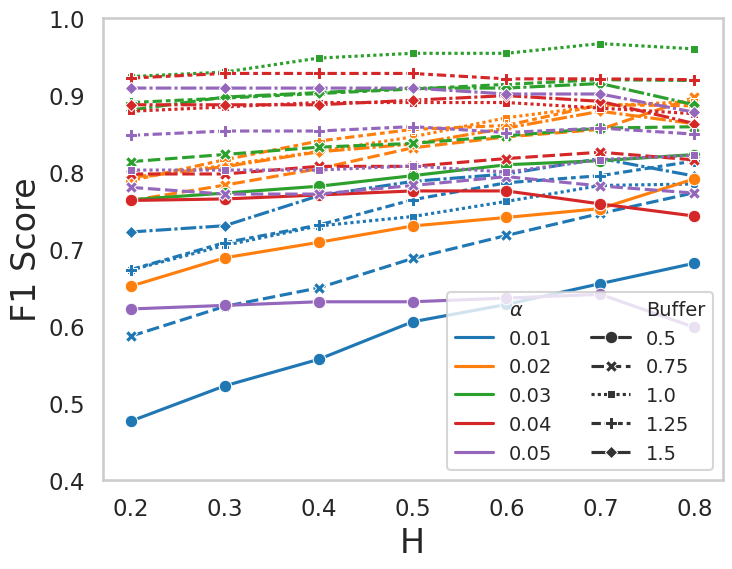

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/home/debasish/Documents/YOLOv8/reversals_gt/reversal_parameter_optimization_with_tolerance.csv")

df = df.sort_values(by=["ALPHA", "BUFFER", "H"])

sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(8, 6))

palette = sns.color_palette("tab10")

ax = sns.lineplot(
    data=df,
    x="H",
    y="f1",
    hue="ALPHA",
    style="BUFFER",
    markers=True,
    dashes=True,
    palette=palette
)

plt.xlabel("H", fontsize=24)
plt.ylabel("F1 Score", fontsize=24)
plt.ylim(0.4, 1)
plt.grid(False)

handles, labels = ax.get_legend_handles_labels()

new_labels = []
for label in labels:
    if label == "ALPHA":
        new_labels.append(r'$\alpha$')
    elif label == "BUFFER":
        new_labels.append("Buffer")
    else:
        new_labels.append(label)

plt.legend(
    handles,
    new_labels,
    ncols=2,
    fontsize=14,
    loc="lower right",
    frameon=True
)

plt.show()